In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import folium
import geopandas as gpd
import branca
from shapely import wkt
import ast
import os
from shapely.geometry import LineString, MultiLineString

<h1>General Stats</h1>

In [ ]:
BUFFER_METERS = 15
scored_df = pd.read_csv(f"../output/scored_edges_no_distance.csv")
print(scored_df.head())
print('desc')
print(scored_df.describe())
print('info')
print(scored_df.info())

          u            v  key      osm_id      highway  oneway reversed  \
0  29938143    321336630    0  1314104307      footway   False    False   
1  30343852  10554039243    0   995947420  residential   False     True   
2  30343857  10594455028    0     6444537      primary   False    False   
3  30345462  10711199577    0     6351990     tertiary   False    False   
4  53008651    540175073    0     6325234      service   False    False   

      length lanes maxspeed               name access   service bridge tunnel  \
0  13.325166   NaN      NaN                NaN    NaN       NaN    NaN    NaN   
1  12.913173     2   20 mph  Republican Street    NaN       NaN    NaN    NaN   
2  13.165858     4   25 mph   5th Avenue North    NaN       NaN    NaN    NaN   
3  11.761364     2   25 mph   Convention Place     no       NaN    NaN    NaN   
4  14.523488   NaN      NaN                NaN    NaN  driveway    NaN    NaN   

   ref  AccessScore                                           

<h1>Boxplot of Distributions Across Buffers</h1>

In [ ]:
nums = [5, 10, 15, 20, 25]
data = []

for num in nums:
    df = pd.read_csv(f'../output/buffers/scored_edges_buffer_{num}.csv')
    data.append(df['AccessScore_slope'].dropna())

# Choose a color palette
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(10, 6))
box = ax.boxplot(data, patch_artist=True, labels=[str(n) for n in nums])

# Color each box
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Style whiskers, medians, caps
for whisker in box['whiskers']:
    whisker.set(color='#333', linewidth=2)
for median in box['medians']:
    median.set(color='black', linewidth=2)
for cap in box['caps']:
    cap.set(color='#333', linewidth=2)

ax.set_xlabel('Buffer Size (meters)', fontsize=14)
ax.set_ylabel('AccessScore', fontsize=14)
ax.set_title('AccessScore Distribution by Buffer Size', fontsize=16)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

<h1>AccessScore Histogram Distrubution</h1>

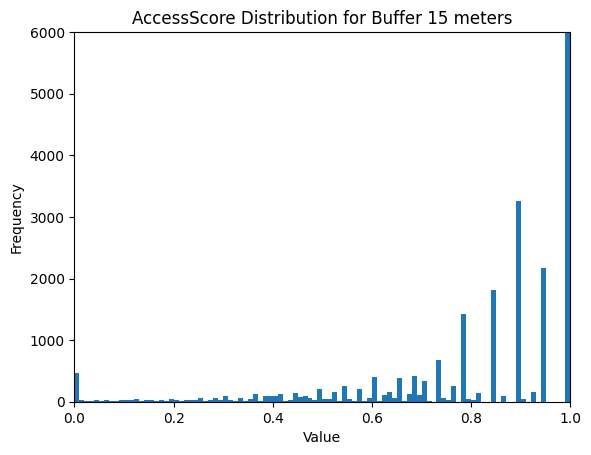

In [ ]:
plt.hist(scored_df['AccessScore'], bins=100)
plt.xlim(0, 1)
plt.ylim(0, 6000)
plt.title('AccessScore Distribution for Buffer ' + str(BUFFER_METERS) + ' meters')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

<h1>Interactive Colored AccessScore Graph</h1>

C:\Users\vzhang\AppData\Local\Temp\ipykernel_1528\3354596580.py:8: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  scored_df = pd.read_csv(r"C:\Users\vzhang\workplace\EquitableWalkability\STARSWalkability\routing\all_scored_edges_filtered_with_ai.csv")


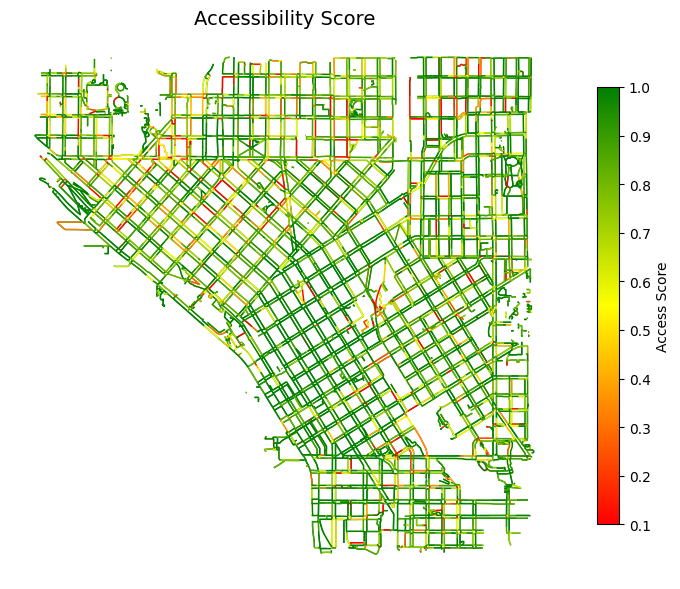

In [7]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely import wkt
from matplotlib.colors import LinearSegmentedColormap

# Load your data
scored_df = pd.read_csv(r"C:\Users\vzhang\workplace\EquitableWalkability\STARSWalkability\routing\all_scored_edges_filtered_with_ai.csv")
scored_df['geometry'] = scored_df['geometry'].apply(wkt.loads)
gdf = gpd.GeoDataFrame(scored_df, geometry='geometry', crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, "red"), (0.5, "yellow"), (1.0, "green")]
)

# Use AccessScore for color, with reversed colormap (so 0=red, 1=green)
gdf.plot(
    column="access_score",  # column to color by
    cmap=cmap,       # same red-yellow-green scale
    linewidth=1,
    ax=ax,
    legend=True,
    legend_kwds={
        "label": "Access Score",
        "shrink": 0.8
    }
)

# Clean styling
ax.set_axis_off()
ax.set_title("Accessibility Score", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
scored_df = pd.read_csv(f"../output/accessibility_scored_edges_slope.csv")

# 3. Parse WKT strings into shapely geometries
scored_df['geometry'] = scored_df['geometry'].apply(wkt.loads)  # Ensure geometries are shapely

# 4. Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(scored_df, geometry='geometry', crs='EPSG:4326')  # WGS84 lat/lon projection

# Determine the center of the map
bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
center_lat = (bounds[1] + bounds[3]) / 2
center_lon = (bounds[0] + bounds[2]) / 2

# Initialize map
m = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles="cartodbpositron")

# Create a linear colormap from red (0) to green (1)
colormap = branca.colormap.LinearColormap(
    colors=["red", "yellow", "green"],
    vmin=0,
    vmax=1,
    caption="Access Score"
)
colormap.add_to(m)

# Add each LineString or MultiLineString to the map
for _, row in gdf.iterrows():
    geom = row.geometry

    # Get list of LineStrings to plot
    if isinstance(geom, LineString):
        lines = [geom]
    elif isinstance(geom, MultiLineString):
        lines = list(geom.geoms)
    else:
        continue  # skip unsupported geometry types

    # Parse and format notes
    try:
        notes_list = ast.literal_eval(row.sidewalk_notes)
        slope_list = ast.literal_eval(row.slope_notes)
    except Exception as e:
        notes_list = f"Failed to parse notes: {e}"
        slope_list = {"max_slope": 0, 'elevation_change':0}

    if isinstance(notes_list, list):
        notes_text = ""
        for note in notes_list:
            for key, value_list in note.items():
                if isinstance(value_list, list) and len(value_list) > 0:
                    try:
                        occurrences, severity = value_list[0], value_list[1]
                        notes_text += f"{key}: {int(occurrences)} occurrence(s), avg severity {round(severity, 2)}<br>"
                    except Exception:
                        notes_text += f"{key}: invalid value format<br>"
    else:
        notes_text = "No accessibility concerns"

    # notes_text_1 = f"Maximum Slope of Segment: {round(slope_list['max_slope'] * 100, 2)} %<br>Elevation gain/decline: {round(slope_list['elevation_change'], 2)} meters<br>"

    # Full tooltip text
    tooltip_html = f"""
    <b>Access score:</b> {row.AccessScore:.2f}<br>
    <b>Notes:</b><br>{notes_text}<br>
    {slope_list}
    """

    # <b>Slope/Elevation:</b><br>{notes_text_1}
    # """

    # Plot each LineString
    for line in lines:
        coords = [(pt[1], pt[0]) for pt in line.coords]  # folium expects (lat, lon)
        folium.PolyLine(
            locations=coords,
            color=colormap(row.AccessScore),
            weight=5,
            opacity=0.8,
            tooltip=folium.Tooltip(tooltip_html, sticky=True)
        ).add_to(m)
        
# Save the map
output_path = os.path.join(os.getcwd(), "access_map_no_distance.html")
m.save(output_path)
m

NameError: name 'pd' is not defined

C:\Users\vzhang\AppData\Local\Temp\ipykernel_1528\1428628089.py:7: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  scored_df = pd.read_csv(r"C:\Users\vzhang\workplace\EquitableWalkability\STARSWalkability\routing\all_scored_edges_filtered_with_ai.csv")


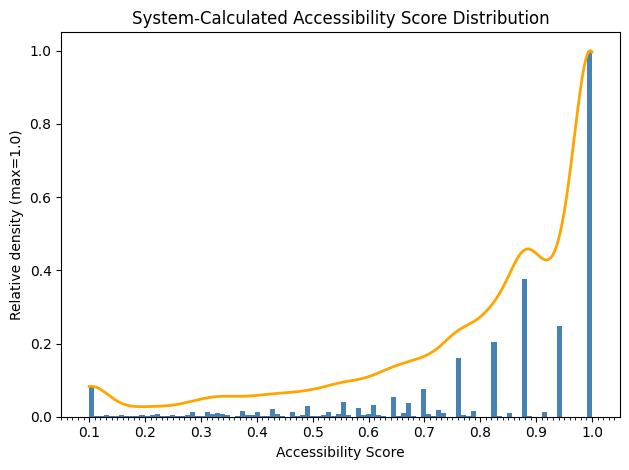

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Load your data
scored_df = pd.read_csv(r"C:\Users\vzhang\workplace\EquitableWalkability\STARSWalkability\routing\all_scored_edges_filtered_with_ai.csv")
data = scored_df['access_score'].dropna()

# Histogram (get density values first)
counts, bins, _ = plt.hist(
    data,
    bins=100,
    density=True,
    alpha=0.0  # invisible, we'll replot normalized bars
)

# Normalize histogram to max=1
counts = counts / counts.max()

plt.clf()  # clear dummy plot

plt.bar(
    (bins[:-1] + bins[1:]) / 2,  # bin centers
    counts,
    width=(bins[1] - bins[0]),
    alpha=1,
    color='steelblue'
)

# KDE curve
x_vals = np.linspace(data.min(), data.max(), 500)
kde = gaussian_kde(data)
kde_vals = kde(x_vals)
kde_vals = kde_vals / kde_vals.max()  # normalize to max=1

plt.plot(x_vals, kde_vals, color='orange', linewidth=2)

# Labels and title
plt.title('System-Calculated Accessibility Score Distribution')
plt.ylabel('Relative density (max=1.0)')
plt.xlabel('Accessibility Score')

new_tick_locations = np.linspace(0, 1, num=11)
plt.xticks(new_tick_locations)
plt.xticks(np.arange(0, 1.05, 0.01), minor=True)

plt.ylim(0, 1.05)
plt.xlim(0.05, 1.05)
plt.tight_layout()
plt.show()


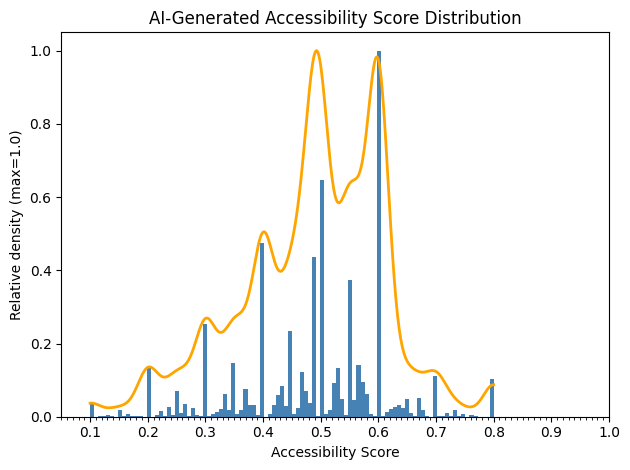

In [48]:
data = scored_df['AI_avg_accessibility_score'].dropna()

# Histogram (get density values first)
counts, bins, _ = plt.hist(
    data,
    bins=100,
    density=True,
    alpha=0.0  # invisible, we'll replot normalized bars
)

# Normalize histogram to max=1
counts = counts / counts.max()

plt.clf()  # clear dummy plot

plt.bar(
    (bins[:-1] + bins[1:]) / 2,  # bin centers
    counts,
    width=(bins[1] - bins[0]),
    alpha=1,
    color='steelblue'
)

# KDE curve
x_vals = np.linspace(data.min(), data.max(), 500)
kde = gaussian_kde(data)
kde_vals = kde(x_vals)
kde_vals = kde_vals / kde_vals.max()  # normalize to max=1

plt.plot(x_vals, kde_vals, color='orange', linewidth=2)

# Labels and title
plt.title('AI-Generated Accessibility Score Distribution')
plt.ylabel('Relative density (max=1.0)')
plt.xlabel('Accessibility Score')

new_tick_locations = np.linspace(0, 1, num=11)
plt.xticks(new_tick_locations)
plt.xticks(np.arange(0, 1, 0.01), minor=True)

plt.xlim(0.05, 1)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


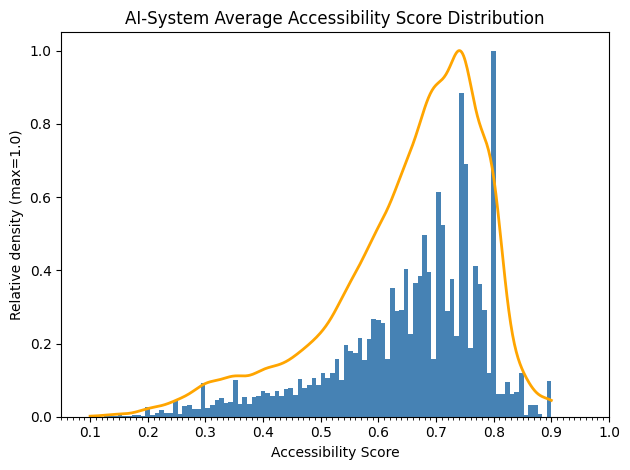

In [49]:
data = scored_df['ai_access_average'].dropna()

# Histogram (get density values first)
counts, bins, _ = plt.hist(
    data,
    bins=100,
    density=True,
    alpha=0.0  # invisible, we'll replot normalized bars
)

# Normalize histogram to max=1
counts = counts / counts.max()

plt.clf()  # clear dummy plot

plt.bar(
    (bins[:-1] + bins[1:]) / 2,  # bin centers
    counts,
    width=(bins[1] - bins[0]),
    alpha=1,
    color='steelblue'
)

# KDE curve
x_vals = np.linspace(data.min(), data.max(), 500)
kde = gaussian_kde(data)
kde_vals = kde(x_vals)
kde_vals = kde_vals / kde_vals.max()  # normalize to max=1

plt.plot(x_vals, kde_vals, color='orange', linewidth=2)

# Labels and title
plt.title('AI-System Average Accessibility Score Distribution')
plt.ylabel('Relative density (max=1.0)')
plt.xlabel('Accessibility Score')

new_tick_locations = np.linspace(0, 1, num=11)
plt.xticks(new_tick_locations)
plt.xticks(np.arange(0, 1, 0.01), minor=True)

plt.xlim(0.05, 1)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()
